# CDS Raw Market Data Analysis

This notebook provides a comprehensive analysis of raw CDS market data across different maturities (1Y, 3Y, 5Y), including:
- Summary statistics for each company and maturity
- Missing data analysis
- Sequential repeat detection (data staleness)
- Liquidity metrics

Author: Analysis Date: 2024

## 1. Import Required Libraries

Import necessary libraries for data analysis and visualization.

In [24]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load CDS Data

Load the CDS data from Excel files for all three maturities (1Y, 3Y, 5Y).

In [25]:
from pathlib import Path
import pandas as pd

# Resolve data/input path using relative paths only.
candidate_paths = [
    Path.cwd() / "data" / "input",
    Path.cwd().parent / "data" / "input",
    Path.cwd().parent.parent / "data" / "input",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    searched = "\n".join(str(p) for p in candidate_paths)
    raise FileNotFoundError(f"Could not find data/input directory. Checked:\n{searched}")

print(f"Using data path: {data_path}")

# Load CDS data for different maturities
cds_1y = pd.read_excel(data_path / "CDS_1y_mat_data.xlsx", index_col=0, parse_dates=True)
cds_3y = pd.read_excel(data_path / "CDS_3y_mat_data.xlsx", index_col=0, parse_dates=True)
cds_5y = pd.read_excel(data_path / "CDS_5y_mat_data.xlsx", index_col=0, parse_dates=True)

Using data path: c:\Users\Chase\Downloads\Seminar QF\Seminar QF\data\input


## 3. Summary Statistics by Company and Maturity

Calculate comprehensive summary statistics for each company across all maturities.

In [26]:
# Function to calculate comprehensive summary statistics
def calculate_summary_stats(df, maturity_name):
    """
    Calculate summary statistics for each company in the dataframe.

    Parameters:
    - df: DataFrame with CDS spreads
    - maturity_name: String identifier for the maturity

    Returns:
    - DataFrame with summary statistics
    """
    stats_dict = {}

    for company in df.columns:
        # Coerce to numeric so text artifacts do not break summary stats.
        company_data = pd.to_numeric(df[company], errors="coerce").dropna()

        if len(company_data) > 0:
            mean_val = company_data.mean()
            std_val = company_data.std()
            stats_dict[company] = {
                "Count": len(company_data),
                "Mean": mean_val,
                "Median": company_data.median(),
                "Std": std_val,
                "Min": company_data.min(),
                "Max": company_data.max(),
                "Q25": company_data.quantile(0.25),
                "Q75": company_data.quantile(0.75),
                "Range": company_data.max() - company_data.min(),
                "CV": (std_val / mean_val) if mean_val != 0 else np.nan,
                "Skewness": company_data.skew(),
                "Kurtosis": company_data.kurtosis(),
            }
        else:
            stats_dict[company] = {
                key: np.nan
                for key in [
                    "Count",
                    "Mean",
                    "Median",
                    "Std",
                    "Min",
                    "Max",
                    "Q25",
                    "Q75",
                    "Range",
                    "CV",
                    "Skewness",
                    "Kurtosis",
                ]
            }

    stats_df = pd.DataFrame(stats_dict).T
    stats_df.index.name = "Company"

    return stats_df


# Calculate summary statistics for all maturities
print("=" * 80)
print("SUMMARY STATISTICS BY COMPANY AND MATURITY")
print("=" * 80)

stats_1y = calculate_summary_stats(cds_1y, "1Y")
stats_3y = calculate_summary_stats(cds_3y, "3Y")
stats_5y = calculate_summary_stats(cds_5y, "5Y")

print("\n### 1-YEAR MATURITY SUMMARY STATISTICS ###")
display(stats_1y)

print("\n### 3-YEAR MATURITY SUMMARY STATISTICS ###")
display(stats_3y)

print("\n### 5-YEAR MATURITY SUMMARY STATISTICS ###")
display(stats_5y)

SUMMARY STATISTICS BY COMPANY AND MATURITY

### 1-YEAR MATURITY SUMMARY STATISTICS ###


,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV,Skewness,Kurtosis
Company,,,,,,,,,,,,
Unnamed: 1,4174.0000,19.6703,15.3950,12.9232,7.4300,108.9300,11.3300,21.3775,101.5000,0.6570,2.5128,7.8509
2010-01-01 00:00:00,4174.0000,32.4420,26.4600,19.0934,7.0290,118.1900,16.7250,43.8000,111.1610,0.5885,1.1625,1.5101
Unnamed: 3,4174.0000,35.9491,29.1950,29.1230,3.6600,204.1420,13.4125,48.4700,200.4820,0.8101,1.8242,4.2465
Unnamed: 4,4174.0000,18.3178,11.5100,17.0036,3.7000,124.5500,8.2500,19.8825,120.8500,0.9283,2.4803,6.7032
Unnamed: 5,2780.0000,29.4120,30.6200,4.3622,6.0000,42.6400,30.6200,30.6200,36.6400,0.1483,-3.0716,10.8190
Unnamed: 6,2780.0000,250.3394,251.5400,2.6837,239.9200,251.5400,251.5400,251.5400,11.6200,0.0107,-2.2941,4.1827
Unnamed: 7,4174.0000,40.2978,19.3800,54.4682,5.8700,321.3499,13.0100,37.5075,315.4799,1.3516,2.9136,8.5186
Unnamed: 8,2780.0000,24.7080,20.3600,16.4623,4.0900,107.4800,11.5500,29.8825,103.3900,0.6663,1.4870,2.1225
Unnamed: 9,4174.0000,15.0651,10.6950,13.0958,2.6400,112.3000,7.5700,16.2255,109.6600,0.8693,2.7053,9.4428



### 3-YEAR MATURITY SUMMARY STATISTICS ###


,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV,Skewness,Kurtosis
Company,,,,,,,,,,,,
Unnamed: 1,4174.0000,38.9992,33.3275,18.6844,16.2700,137.4250,26.0300,46.4000,121.1550,0.4791,1.8015,3.9205
2010-01-01 00:00:00,4174.0000,52.5658,50.7400,22.0426,22.1900,175.2800,39.8675,65.2200,153.0900,0.4193,1.4466,5.3648
Unnamed: 3,4174.0000,62.8951,54.2915,38.9303,9.2200,231.6500,29.7700,94.0200,222.4300,0.6190,0.9632,0.8081
Unnamed: 4,4174.0000,32.4173,23.7150,22.7381,9.3100,151.0800,17.1700,39.0360,141.7700,0.7014,1.8689,3.4929
Unnamed: 5,2780.0000,43.9148,44.2900,4.4726,21.1200,69.2800,44.2900,44.2900,48.1600,0.1018,-0.7817,12.4899
Unnamed: 6,2780.0000,253.4947,254.1100,1.3552,248.3800,254.1100,254.0600,254.1100,5.7300,0.0053,-2.2308,3.7934
Unnamed: 7,4174.0000,62.1756,39.5600,63.0906,15.6200,360.3999,25.6025,63.3350,344.7799,1.0147,2.4866,6.1287
Unnamed: 8,2780.0000,42.7869,26.2450,25.7993,20.8700,164.0400,26.0300,57.4350,143.1700,0.6030,1.4908,1.4427
Unnamed: 9,2780.0000,44.5445,38.0500,25.7029,10.2300,165.1800,25.5600,52.2900,154.9500,0.5770,1.3954,1.7879



### 5-YEAR MATURITY SUMMARY STATISTICS ###


,Count,Mean,Median,Std,Min,Max,Q25,Q75,Range,CV,Skewness,Kurtosis
Company,,,,,,,,,,,,
Unnamed: 1,4174.0000,59.8521,52.8200,23.7312,30.5300,170.1600,41.5800,69.7225,139.6300,0.3965,1.6403,2.8880
2010-01-01 00:00:00,4174.0000,73.4765,75.8585,26.9293,29.6900,257.7698,65.0422,82.2100,228.0798,0.3665,2.7850,14.8848
Unnamed: 3,4174.0000,89.2375,80.4400,44.0714,22.0400,264.7200,54.0000,130.6400,242.6800,0.4939,0.6102,-0.1507
Unnamed: 4,4174.0000,48.3462,37.8650,28.4048,16.7400,176.4000,29.1025,60.3875,159.6600,0.5875,1.5000,1.7054
Unnamed: 5,3324.0000,66.6869,69.9100,8.6804,40.8300,98.0300,69.9100,69.9100,57.2000,0.1302,-0.9984,1.9380
Unnamed: 6,4174.0000,84.7969,59.2800,68.6770,27.5100,388.7400,43.0005,88.7300,361.2300,0.8099,2.1741,4.5000
Unnamed: 7,4174.0000,48.4286,42.1350,23.1266,21.5800,178.5000,32.0325,55.3700,156.9200,0.4775,2.0650,5.4026
Unnamed: 8,4174.0000,65.8307,60.9630,23.8264,25.9600,154.9500,48.1900,79.1600,128.9900,0.3619,0.7032,-0.0118
Unnamed: 9,4174.0000,67.4880,61.0350,26.5994,30.5700,188.6200,47.3525,78.6390,158.0500,0.3941,1.3346,1.6281


In [27]:
# Export summary statistics to Excel
output_candidates = [
    Path.cwd() / "results",
    Path.cwd().parent / "results",
    Path.cwd() / "data" / "output",
]
output_path = next((p for p in output_candidates if p.exists()), output_candidates[0])
output_path.mkdir(parents=True, exist_ok=True)

output_file = output_path / "cds_summary_statistics.xlsx"
with pd.ExcelWriter(output_file) as writer:
    stats_1y.to_excel(writer, sheet_name="1Y_Maturity")
    stats_3y.to_excel(writer, sheet_name="3Y_Maturity")
    stats_5y.to_excel(writer, sheet_name="5Y_Maturity")

print(f"Summary statistics exported to: {output_file}")

Summary statistics exported to: c:\Users\Chase\Downloads\Seminar QF\Seminar QF\notebooks\data\output\cds_summary_statistics.xlsx


## 4. Missing Data Analysis

Analyze missing values (NAs) for each company at each maturity level.

In [28]:
# Function to analyze missing data
def analyze_missing_data(df, maturity_name):
    """
    Analyze missing data patterns in the CDS spreads.
    
    Parameters:
    - df: DataFrame with CDS spreads
    - maturity_name: String identifier for the maturity
    
    Returns:
    - DataFrame with missing data analysis
    """
    missing_dict = {}
    total_observations = len(df)
    
    for company in df.columns:
        na_count = df[company].isna().sum()
        na_percentage = (na_count / total_observations) * 100
        first_valid = df[company].first_valid_index()
        last_valid = df[company].last_valid_index()
        
        missing_dict[company] = {
            'Total_Observations': total_observations,
            'NA_Count': na_count,
            'Non_NA_Count': total_observations - na_count,
            'NA_Percentage': na_percentage,
            'Data_Availability': 100 - na_percentage,
            'First_Valid_Date': first_valid,
            'Last_Valid_Date': last_valid
        }
    
    missing_df = pd.DataFrame(missing_dict).T
    missing_df.index.name = 'Company'
    
    return missing_df

# Analyze missing data for all maturities
print("="*80)
print("MISSING DATA ANALYSIS BY COMPANY AND MATURITY")
print("="*80)

missing_1y = analyze_missing_data(cds_1y, '1Y')
missing_3y = analyze_missing_data(cds_3y, '3Y')
missing_5y = analyze_missing_data(cds_5y, '5Y')

print("\n### 1-YEAR MATURITY - MISSING DATA ###")
display(missing_1y.sort_values('NA_Percentage', ascending=False))

print("\n### 3-YEAR MATURITY - MISSING DATA ###")
display(missing_3y.sort_values('NA_Percentage', ascending=False))

print("\n### 5-YEAR MATURITY - MISSING DATA ###")
display(missing_5y.sort_values('NA_Percentage', ascending=False))

MISSING DATA ANALYSIS BY COMPANY AND MATURITY

### 1-YEAR MATURITY - MISSING DATA ###


,Total_Observations,NA_Count,Non_NA_Count,NA_Percentage,Data_Availability,First_Valid_Date,Last_Valid_Date
Company,,,,,,,
Unnamed: 42,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 41,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 40,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 5,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 6,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 39,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 8,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 33,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 28,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00



### 3-YEAR MATURITY - MISSING DATA ###


,Total_Observations,NA_Count,Non_NA_Count,NA_Percentage,Data_Availability,First_Valid_Date,Last_Valid_Date
Company,,,,,,,
Unnamed: 22,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 13,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 39,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 38,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 5,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 6,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 37,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 8,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00
Unnamed: 9,4179,1396,2783,33.4051,66.5949,Name,2025-12-31 00:00:00



### 5-YEAR MATURITY - MISSING DATA ###


,Total_Observations,NA_Count,Non_NA_Count,NA_Percentage,Data_Availability,First_Valid_Date,Last_Valid_Date
Company,,,,,,,
Unnamed: 33,4178,1282,2896,30.6845,69.3155,Name,2025-12-31 00:00:00
Unnamed: 5,4178,852,3326,20.3925,79.6075,Name,2025-12-31 00:00:00
Unnamed: 17,4178,384,3794,9.1910,90.8090,Name,2025-12-31 00:00:00
Unnamed: 1,4178,2,4176,0.0479,99.9521,Name,2025-12-31 00:00:00
Unnamed: 29,4178,2,4176,0.0479,99.9521,Name,2025-12-31 00:00:00
Unnamed: 23,4178,2,4176,0.0479,99.9521,Name,2025-12-31 00:00:00
Unnamed: 24,4178,2,4176,0.0479,99.9521,Name,2025-12-31 00:00:00
Unnamed: 25,4178,2,4176,0.0479,99.9521,Name,2025-12-31 00:00:00
Unnamed: 26,4178,2,4176,0.0479,99.9521,Name,2025-12-31 00:00:00


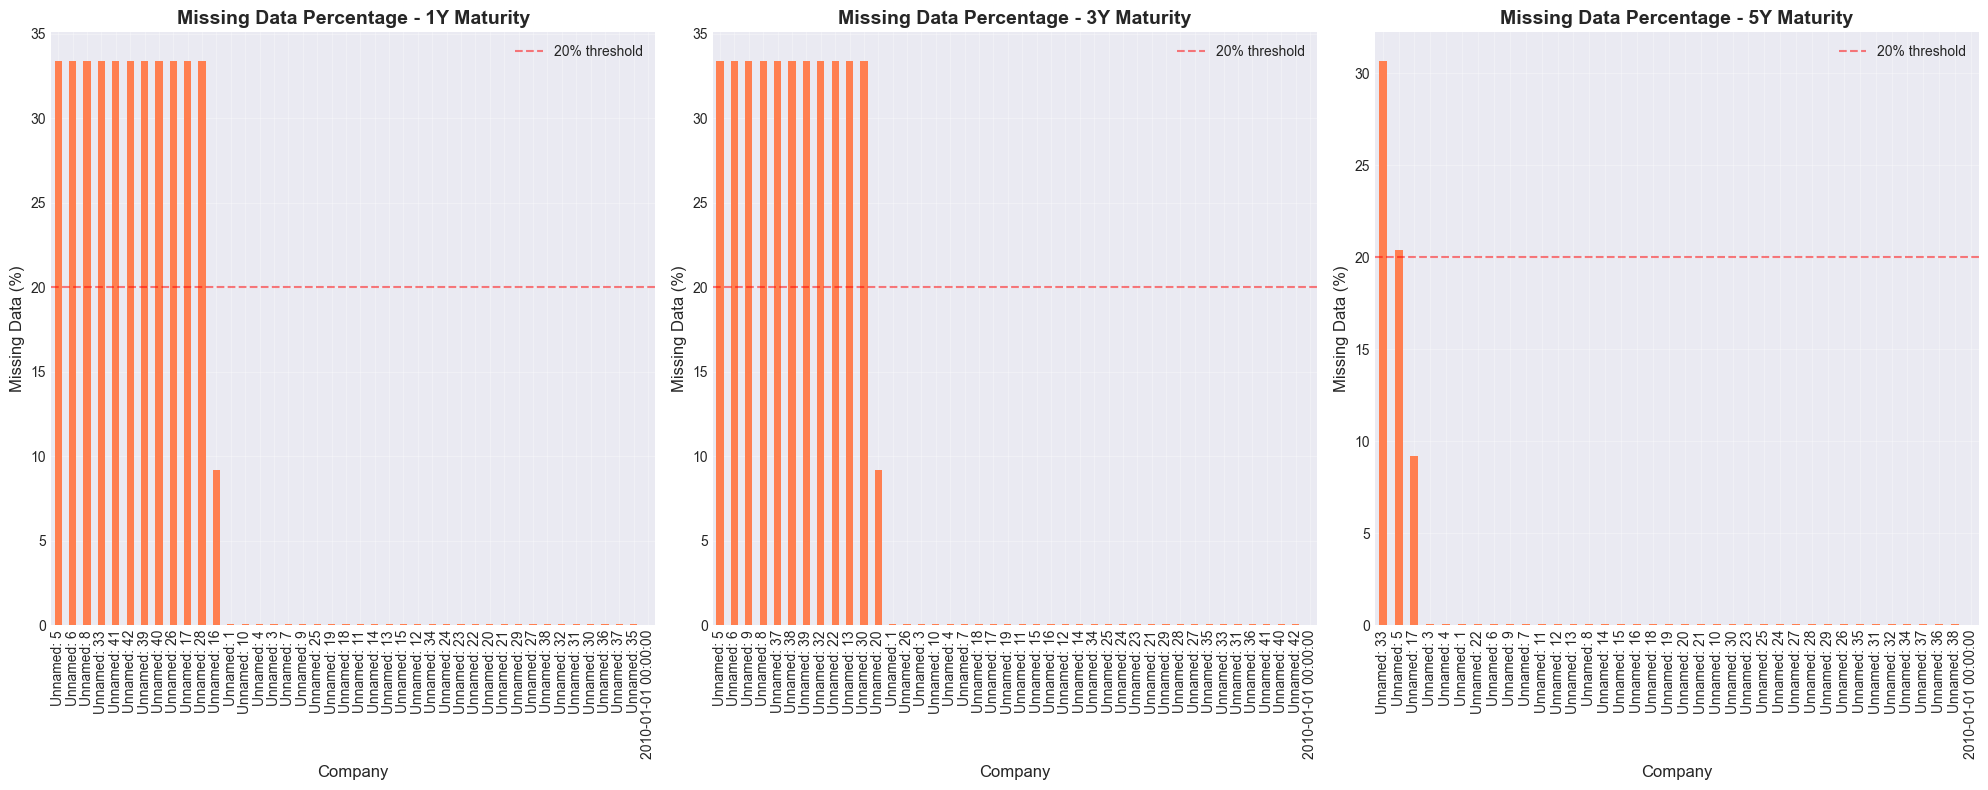


Missing data visualization saved!


In [29]:
# Visualize missing data patterns
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for idx, (df, maturity, ax) in enumerate(zip([cds_1y, cds_3y, cds_5y], 
                                               ['1Y', '3Y', '5Y'], 
                                               axes)):
    # Calculate missing percentage for each company
    missing_pct = (df.isna().sum() / len(df)) * 100
    missing_pct = missing_pct.sort_values(ascending=False)
    
    # Plot
    missing_pct.plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Missing Data Percentage - {maturity} Maturity', fontsize=14, fontweight='bold')
    ax.set_xlabel('Company', fontsize=12)
    ax.set_ylabel('Missing Data (%)', fontsize=12)
    ax.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(output_path / 'missing_data_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMissing data visualization saved!")

## 5. Sequential Repeat Detection

Detect and count consecutive identical CDS spread values (data staleness indicator).

In [30]:
# Function to detect sequential repeats
def detect_sequential_repeats(df, maturity_name):
    """
    Detect consecutive identical values in CDS spreads (stale data indicator).
    
    Parameters:
    - df: DataFrame with CDS spreads
    - maturity_name: String identifier for the maturity
    
    Returns:
    - DataFrame with sequential repeat analysis
    """
    repeat_dict = {}
    
    for company in df.columns:
        company_data = df[company].dropna()
        
        if len(company_data) > 1:
            # Identify where values change
            value_changes = company_data != company_data.shift(1)
            
            # Create groups of consecutive identical values
            groups = value_changes.cumsum()
            
            # Calculate repeat sequences
            repeat_lengths = company_data.groupby(groups).size()
            
            # Get sequences with more than 1 occurrence (actual repeats)
            actual_repeats = repeat_lengths[repeat_lengths > 1]
            
            repeat_dict[company] = {
                'Total_Valid_Observations': len(company_data),
                'Total_Repeat_Sequences': len(actual_repeats),
                'Total_Repeated_Days': actual_repeats.sum() if len(actual_repeats) > 0 else 0,
                'Max_Consecutive_Repeats': actual_repeats.max() if len(actual_repeats) > 0 else 0,
                'Mean_Repeat_Length': actual_repeats.mean() if len(actual_repeats) > 0 else 0,
                'Median_Repeat_Length': actual_repeats.median() if len(actual_repeats) > 0 else 0,
                'Repeat_Percentage': (actual_repeats.sum() / len(company_data) * 100) if len(actual_repeats) > 0 else 0,
                'Update_Frequency': (len(repeat_lengths) / len(company_data) * 100) if len(company_data) > 0 else 0
            }
        else:
            repeat_dict[company] = {key: 0 for key in ['Total_Valid_Observations', 'Total_Repeat_Sequences', 
                                                        'Total_Repeated_Days', 'Max_Consecutive_Repeats',
                                                        'Mean_Repeat_Length', 'Median_Repeat_Length',
                                                        'Repeat_Percentage', 'Update_Frequency']}
    
    repeat_df = pd.DataFrame(repeat_dict).T
    repeat_df.index.name = 'Company'
    
    return repeat_df

# Detect sequential repeats for all maturities
print("="*80)
print("SEQUENTIAL REPEAT DETECTION (DATA STALENESS ANALYSIS)")
print("="*80)

repeats_1y = detect_sequential_repeats(cds_1y, '1Y')
repeats_3y = detect_sequential_repeats(cds_3y, '3Y')
repeats_5y = detect_sequential_repeats(cds_5y, '5Y')

print("\n### 1-YEAR MATURITY - SEQUENTIAL REPEATS ###")
display(repeats_1y.sort_values('Repeat_Percentage', ascending=False))

print("\n### 3-YEAR MATURITY - SEQUENTIAL REPEATS ###")
display(repeats_3y.sort_values('Repeat_Percentage', ascending=False))

print("\n### 5-YEAR MATURITY - SEQUENTIAL REPEATS ###")
display(repeats_5y.sort_values('Repeat_Percentage', ascending=False))

SEQUENTIAL REPEAT DETECTION (DATA STALENESS ANALYSIS)

### 1-YEAR MATURITY - SEQUENTIAL REPEATS ###


,Total_Valid_Observations,Total_Repeat_Sequences,Total_Repeated_Days,Max_Consecutive_Repeats,Mean_Repeat_Length,Median_Repeat_Length,Repeat_Percentage,Update_Frequency
Company,,,,,,,,
Unnamed: 6,2783.0000,142.0000,2700.0000,2086.0000,19.0141,4.0000,97.0176,8.0848
Unnamed: 26,2783.0000,178.0000,2630.0000,1840.0000,14.7753,3.0000,94.5023,11.8936
Unnamed: 5,2783.0000,77.0000,2556.0000,2367.0000,33.1948,2.0000,91.8433,10.9235
Unnamed: 30,4177.0000,200.0000,3583.0000,2843.0000,17.9150,2.0000,85.7793,19.0089
Unnamed: 42,2783.0000,274.0000,2322.0000,1409.0000,8.4745,3.0000,83.4351,26.4103
Unnamed: 28,2783.0000,294.0000,2286.0000,96.0000,7.7755,3.0000,82.1416,28.4226
Unnamed: 22,4177.0000,461.0000,3375.0000,321.0000,7.3210,3.0000,80.7996,30.2370
Unnamed: 16,3795.0000,93.0000,3032.0000,717.0000,32.6022,2.0000,79.8946,22.5560
Unnamed: 17,2783.0000,268.0000,1759.0000,1080.0000,6.5634,2.0000,63.2052,46.4247



### 3-YEAR MATURITY - SEQUENTIAL REPEATS ###


,Total_Valid_Observations,Total_Repeat_Sequences,Total_Repeated_Days,Max_Consecutive_Repeats,Mean_Repeat_Length,Median_Repeat_Length,Repeat_Percentage,Update_Frequency
Company,,,,,,,,
Unnamed: 5,2783.0000,61.0000,2514.0000,2369.0000,41.2131,2.0000,90.3342,11.8577
Unnamed: 30,2783.0000,179.0000,2331.0000,1837.0000,13.0223,2.0000,83.7585,22.6734
Unnamed: 6,2783.0000,102.0000,2311.0000,2080.0000,22.6569,2.0000,83.0399,20.6252
Unnamed: 34,4177.0000,202.0000,3464.0000,2843.0000,17.1485,2.0000,82.9303,21.9057
Unnamed: 20,3795.0000,86.0000,2983.0000,716.0000,34.6860,2.0000,78.6034,23.6627
Unnamed: 38,2783.0000,220.0000,1956.0000,1409.0000,8.8909,2.0000,70.2839,37.6213
Unnamed: 26,4177.0000,573.0000,2754.0000,322.0000,4.8063,2.0000,65.9325,47.7855
Unnamed: 8,2783.0000,281.0000,1804.0000,1080.0000,6.4199,2.0000,64.8221,45.2749
Unnamed: 22,2783.0000,256.0000,1719.0000,1080.0000,6.7148,2.0000,61.7679,47.4308



### 5-YEAR MATURITY - SEQUENTIAL REPEATS ###


,Total_Valid_Observations,Total_Repeat_Sequences,Total_Repeated_Days,Max_Consecutive_Repeats,Mean_Repeat_Length,Median_Repeat_Length,Repeat_Percentage,Update_Frequency
Company,,,,,,,,
Unnamed: 30,4176.0000,212.0000,3453.0000,2844.0000,16.2877,2.0000,82.6868,22.3898
Unnamed: 5,3326.0000,109.0000,2612.0000,2367.0000,23.9633,2.0000,78.5328,24.7444
Unnamed: 17,3794.0000,91.0000,2937.0000,716.0000,32.2747,2.0000,77.4117,24.9868
Unnamed: 27,4176.0000,242.0000,2428.0000,1837.0000,10.0331,2.0000,58.1418,47.6533
Unnamed: 23,4176.0000,619.0000,2272.0000,322.0000,3.6704,2.0000,54.4061,60.4167
2010-01-01 00:00:00,4178.0000,340.0000,2231.0000,176.0000,6.5618,2.0000,53.3988,54.7391
Unnamed: 31,4176.0000,288.0000,2165.0000,1326.0000,7.5174,2.0000,51.8439,55.0527
Unnamed: 33,2896.0000,52.0000,1359.0000,1246.0000,26.1346,2.0000,46.9268,54.8688
Unnamed: 3,4176.0000,394.0000,1939.0000,858.0000,4.9213,2.0000,46.4320,63.0029


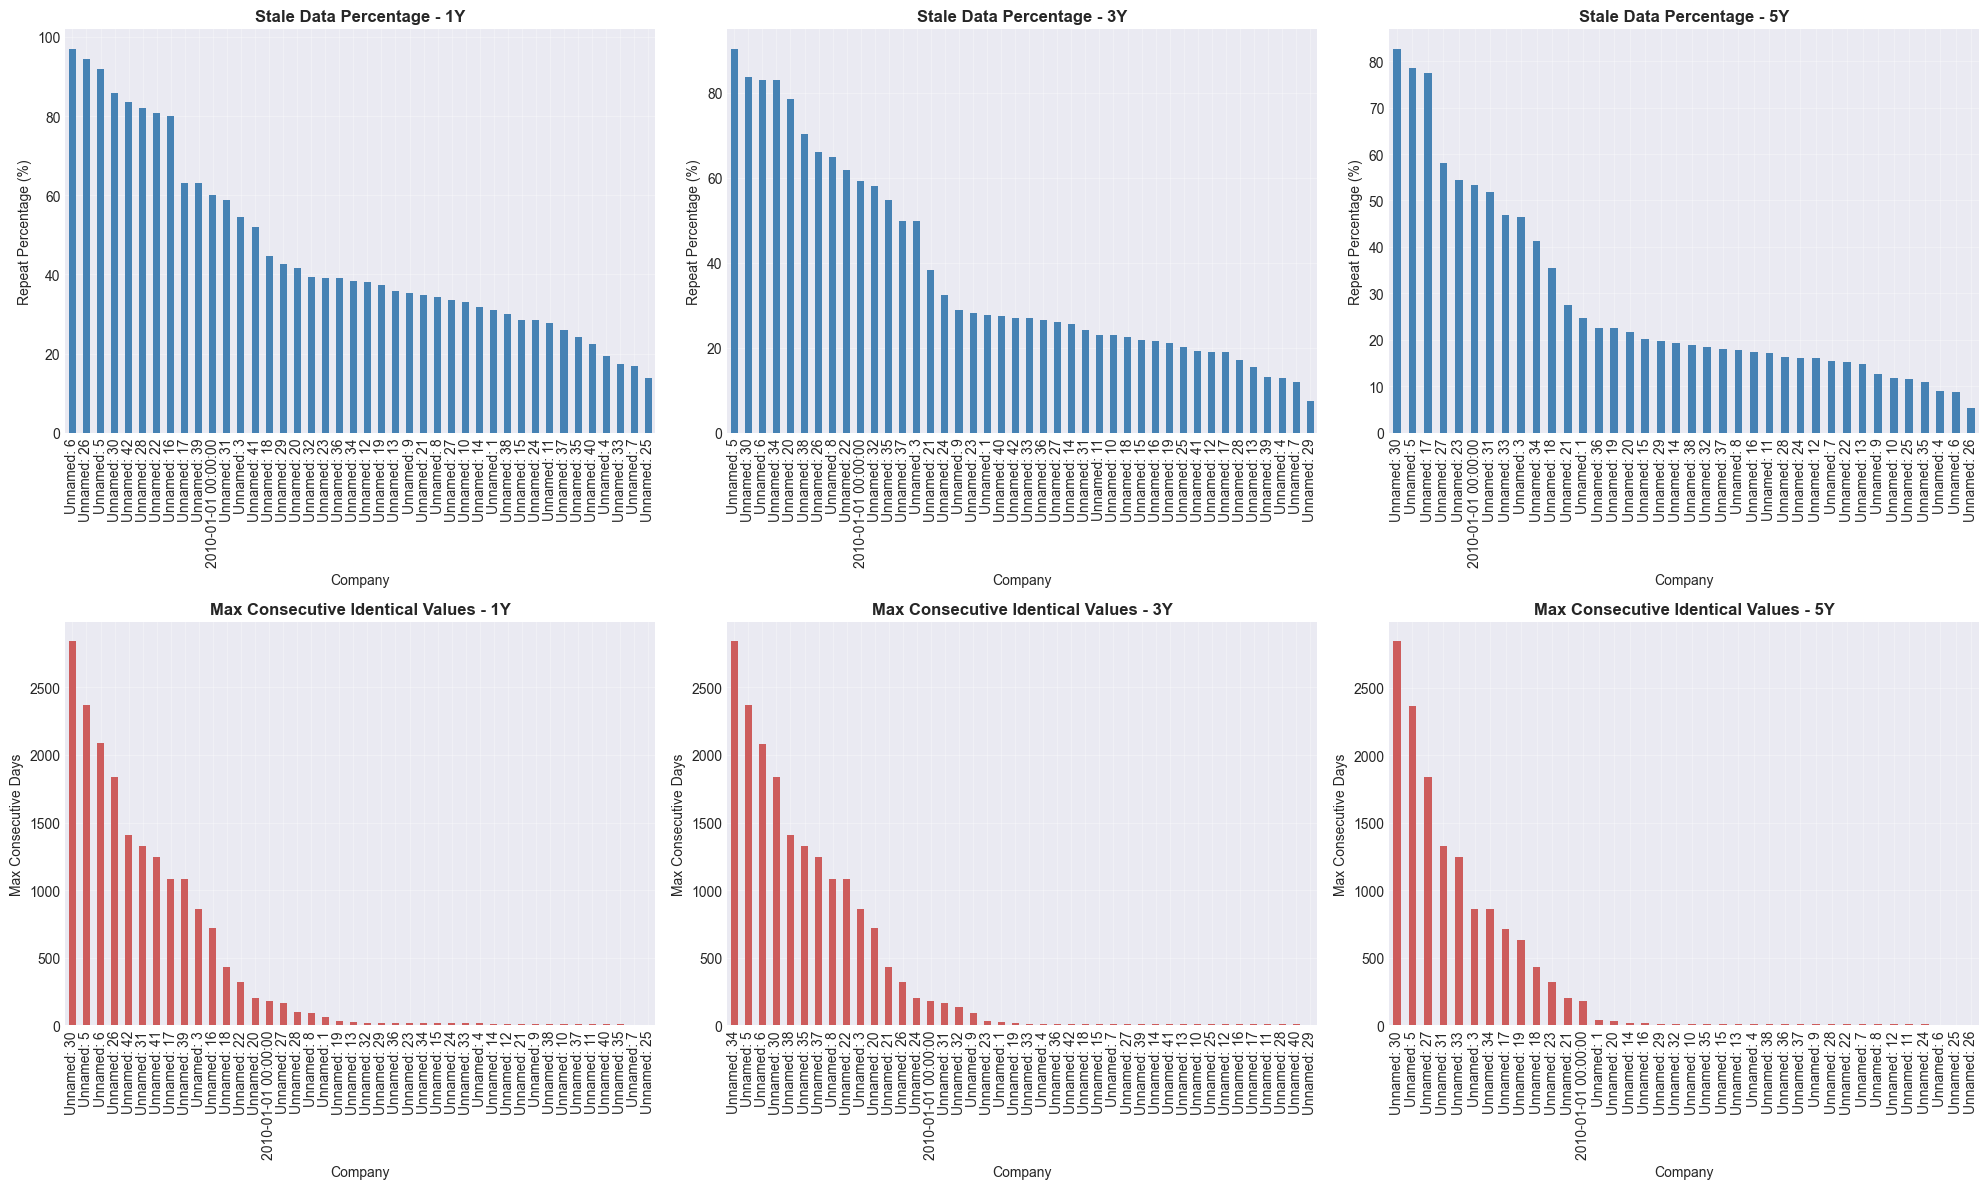


Sequential repeats visualization saved!


In [31]:
# Visualize sequential repeats
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

maturities = ['1Y', '3Y', '5Y']
repeat_dfs = [repeats_1y, repeats_3y, repeats_5y]

for idx, (repeat_df, maturity) in enumerate(zip(repeat_dfs, maturities)):
    # Plot 1: Repeat Percentage
    ax1 = axes[0, idx]
    repeat_pct = repeat_df['Repeat_Percentage'].sort_values(ascending=False)
    repeat_pct.plot(kind='bar', ax=ax1, color='steelblue')
    ax1.set_title(f'Stale Data Percentage - {maturity}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Company', fontsize=10)
    ax1.set_ylabel('Repeat Percentage (%)', fontsize=10)
    ax1.tick_params(axis='x', rotation=90)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Max Consecutive Repeats
    ax2 = axes[1, idx]
    max_repeats = repeat_df['Max_Consecutive_Repeats'].sort_values(ascending=False)
    max_repeats.plot(kind='bar', ax=ax2, color='indianred')
    ax2.set_title(f'Max Consecutive Identical Values - {maturity}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Company', fontsize=10)
    ax2.set_ylabel('Max Consecutive Days', fontsize=10)
    ax2.tick_params(axis='x', rotation=90)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'sequential_repeats_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSequential repeats visualization saved!")

## 6. Liquidity Metrics Calculation

Calculate comprehensive liquidity metrics combining data availability, update frequency, and spread volatility.

In [32]:
# Function to calculate liquidity metrics
def calculate_liquidity_metrics(df, missing_df, repeat_df, maturity_name):
    """
    Calculate comprehensive liquidity metrics for CDS spreads.

    Liquidity Score Components:
    1. Data Availability Ratio (0-100): Percentage of non-missing data
    2. Update Frequency Score (0-100): Based on how often data changes (inverse of staleness)
    3. Spread Volatility Score (0-100): Normalized volatility (higher = more liquid)
    4. Composite Liquidity Score (0-100): Weighted average of above metrics

    Parameters:
    - df: DataFrame with CDS spreads
    - missing_df: DataFrame with missing data analysis
    - repeat_df: DataFrame with sequential repeat analysis
    - maturity_name: String identifier for the maturity

    Returns:
    - DataFrame with liquidity metrics
    """
    liquidity_dict = {}

    for company in df.columns:
        # Component 1: Data Availability (from missing data analysis)
        data_availability = missing_df.loc[company, "Data_Availability"]

        # Component 2: Update Frequency Score (inverse of repeat percentage)
        repeat_pct = repeat_df.loc[company, "Repeat_Percentage"]
        update_frequency_score = 100 - repeat_pct

        # Coerce series to numeric to avoid object/string arithmetic errors.
        company_data = pd.to_numeric(df[company], errors="coerce").dropna()

        # Component 3: Spread Volatility Score
        volatility = 0.0
        volatility_score = 0.0
        avg_daily_change = 0.0
        daily_range_pct = 0.0

        if len(company_data) > 1:
            # Calculate daily returns volatility
            returns = company_data.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
            if len(returns) > 0:
                volatility = float(returns.std() * np.sqrt(252))  # Annualized

            # Normalize volatility (higher volatility = higher score, up to a point)
            volatility_score = min(100.0, volatility * 1000.0)  # Scale factor

            # Component 4: Bid-Ask Proxy (using daily range as percentage of level)
            daily_changes = company_data.diff().abs().dropna()
            if len(daily_changes) > 0:
                avg_daily_change = float(daily_changes.mean())
            avg_level = float(company_data.mean())
            daily_range_pct = (avg_daily_change / avg_level * 100.0) if avg_level != 0 else 0.0

        # Composite Liquidity Score (weighted average)
        # Weights: Data Availability (40%), Update Frequency (30%), Volatility (20%), Range (10%)
        composite_score = (
            0.40 * data_availability
            + 0.30 * update_frequency_score
            + 0.20 * min(volatility_score, 100.0)
            + 0.10 * min(daily_range_pct * 10.0, 100.0)
        )

        liquidity_dict[company] = {
            "Data_Availability_Score": data_availability,
            "Update_Frequency_Score": update_frequency_score,
            "Volatility_Score": min(volatility_score, 100.0),
            "Annualized_Volatility": volatility * 100.0,  # In percentage
            "Avg_Daily_Change_bps": avg_daily_change,
            "Daily_Range_Pct": daily_range_pct,
            "Composite_Liquidity_Score": composite_score,
            "Liquidity_Category": "High" if composite_score >= 70 else ("Medium" if composite_score >= 50 else "Low"),
        }

    liquidity_df = pd.DataFrame(liquidity_dict).T
    liquidity_df.index.name = "Company"

    return liquidity_df


# Calculate liquidity metrics for all maturities
print("=" * 80)
print("LIQUIDITY METRICS ANALYSIS")
print("=" * 80)

liquidity_1y = calculate_liquidity_metrics(cds_1y, missing_1y, repeats_1y, "1Y")
liquidity_3y = calculate_liquidity_metrics(cds_3y, missing_3y, repeats_3y, "3Y")
liquidity_5y = calculate_liquidity_metrics(cds_5y, missing_5y, repeats_5y, "5Y")

print("\n### 1-YEAR MATURITY - LIQUIDITY METRICS ###")
display(liquidity_1y.sort_values("Composite_Liquidity_Score", ascending=False))

print("\n### 3-YEAR MATURITY - LIQUIDITY METRICS ###")
display(liquidity_3y.sort_values("Composite_Liquidity_Score", ascending=False))

print("\n### 5-YEAR MATURITY - LIQUIDITY METRICS ###")
display(liquidity_5y.sort_values("Composite_Liquidity_Score", ascending=False))

LIQUIDITY METRICS ANALYSIS

### 1-YEAR MATURITY - LIQUIDITY METRICS ###


,Data_Availability_Score,Update_Frequency_Score,Volatility_Score,Annualized_Volatility,Avg_Daily_Change_bps,Daily_Range_Pct,Composite_Liquidity_Score,Liquidity_Category
Company,,,,,,,,
Unnamed: 25,99.9521,86.0666,100.0000,108.2765,2.5179,4.9754,90.7763,High
Unnamed: 4,99.9521,80.5602,100.0000,165.0675,1.1915,6.5044,90.6534,High
Unnamed: 7,99.9521,83.1697,100.0000,129.2096,1.8022,4.4723,89.4041,High
Unnamed: 24,99.9521,71.6064,100.0000,159.4263,0.9284,5.6948,87.1576,High
Unnamed: 15,99.9521,71.5825,100.0000,120.6554,1.8852,5.2065,86.6621,High
Unnamed: 35,99.9521,75.8678,100.0000,130.9866,1.4683,3.8097,86.5509,High
Unnamed: 37,99.9521,74.0723,100.0000,111.9944,1.8837,4.3308,86.5333,High
Unnamed: 11,99.9521,72.2768,100.0000,118.1775,0.9703,4.3821,86.0460,High
Unnamed: 38,99.9521,70.0982,100.0000,105.8115,1.0396,3.8963,84.9066,High



### 3-YEAR MATURITY - LIQUIDITY METRICS ###


,Data_Availability_Score,Update_Frequency_Score,Volatility_Score,Annualized_Volatility,Avg_Daily_Change_bps,Daily_Range_Pct,Composite_Liquidity_Score,Liquidity_Category
Company,,,,,,,,
Unnamed: 4,99.9521,87.0242,100.0000,90.0612,1.3250,4.0873,90.1755,High
Unnamed: 29,99.9521,92.6263,100.0000,63.0376,2.9983,2.4038,90.1725,High
Unnamed: 7,99.9521,88.0297,100.0000,75.1998,1.9398,3.1199,89.5097,High
Unnamed: 28,99.9521,82.8825,100.0000,85.5214,1.0977,3.7897,88.6353,High
Unnamed: 12,99.9521,80.8954,100.0000,75.0196,1.3182,3.0702,87.3197,High
Unnamed: 17,99.9521,81.1108,100.0000,70.4428,2.3333,2.9932,87.3073,High
Unnamed: 41,99.9521,80.7278,100.0000,88.6850,1.8699,2.8425,87.0417,High
Unnamed: 19,99.9521,78.9322,100.0000,73.6827,2.1148,3.2953,86.9558,High
Unnamed: 25,99.9521,79.7462,100.0000,66.9202,0.5605,2.4107,86.3154,High



### 5-YEAR MATURITY - LIQUIDITY METRICS ###


,Data_Availability_Score,Update_Frequency_Score,Volatility_Score,Annualized_Volatility,Avg_Daily_Change_bps,Daily_Range_Pct,Composite_Liquidity_Score,Liquidity_Category
Company,,,,,,,,
Unnamed: 26,99.9521,94.7557,100.0000,48.7555,3.2830,1.8159,90.2234,High
Unnamed: 4,99.9521,90.9483,100.0000,62.9782,1.3704,2.8345,90.0999,High
Unnamed: 6,99.9521,91.1877,100.0000,55.0562,1.9871,2.3433,89.6805,High
Unnamed: 25,99.9521,88.4339,100.0000,65.2794,1.2159,2.7828,89.2938,High
Unnamed: 35,99.9521,89.1284,100.0000,56.5148,3.7471,2.4525,89.1719,High
Unnamed: 10,99.9521,88.2663,100.0000,58.1373,1.9495,2.6441,89.1048,High
Unnamed: 9,99.9521,87.3084,100.0000,52.5368,1.4021,2.0776,88.2510,High
Unnamed: 7,99.9521,84.5067,100.0000,46.5008,0.8978,1.8539,87.1868,High
Unnamed: 16,99.9521,82.6149,100.0000,50.3239,2.1128,2.2704,87.0357,High


In [33]:
# Export all analysis results to Excel
with pd.ExcelWriter(output_path / 'cds_complete_analysis.xlsx') as writer:
    # Summary Statistics
    stats_1y.to_excel(writer, sheet_name='Summary_Stats_1Y')
    stats_3y.to_excel(writer, sheet_name='Summary_Stats_3Y')
    stats_5y.to_excel(writer, sheet_name='Summary_Stats_5Y')
    
    # Missing Data
    missing_1y.to_excel(writer, sheet_name='Missing_Data_1Y')
    missing_3y.to_excel(writer, sheet_name='Missing_Data_3Y')
    missing_5y.to_excel(writer, sheet_name='Missing_Data_5Y')
    
    # Sequential Repeats
    repeats_1y.to_excel(writer, sheet_name='Repeats_1Y')
    repeats_3y.to_excel(writer, sheet_name='Repeats_3Y')
    repeats_5y.to_excel(writer, sheet_name='Repeats_3Y')
    
    # Liquidity Metrics
    liquidity_1y.to_excel(writer, sheet_name='Liquidity_1Y')
    liquidity_3y.to_excel(writer, sheet_name='Liquidity_3Y')
    liquidity_5y.to_excel(writer, sheet_name='Liquidity_5Y')

print("Complete analysis exported to: cds_complete_analysis.xlsx")

Complete analysis exported to: cds_complete_analysis.xlsx


## 7. Visualization of Data Quality

Create comprehensive visualizations including heatmaps and comparative charts.

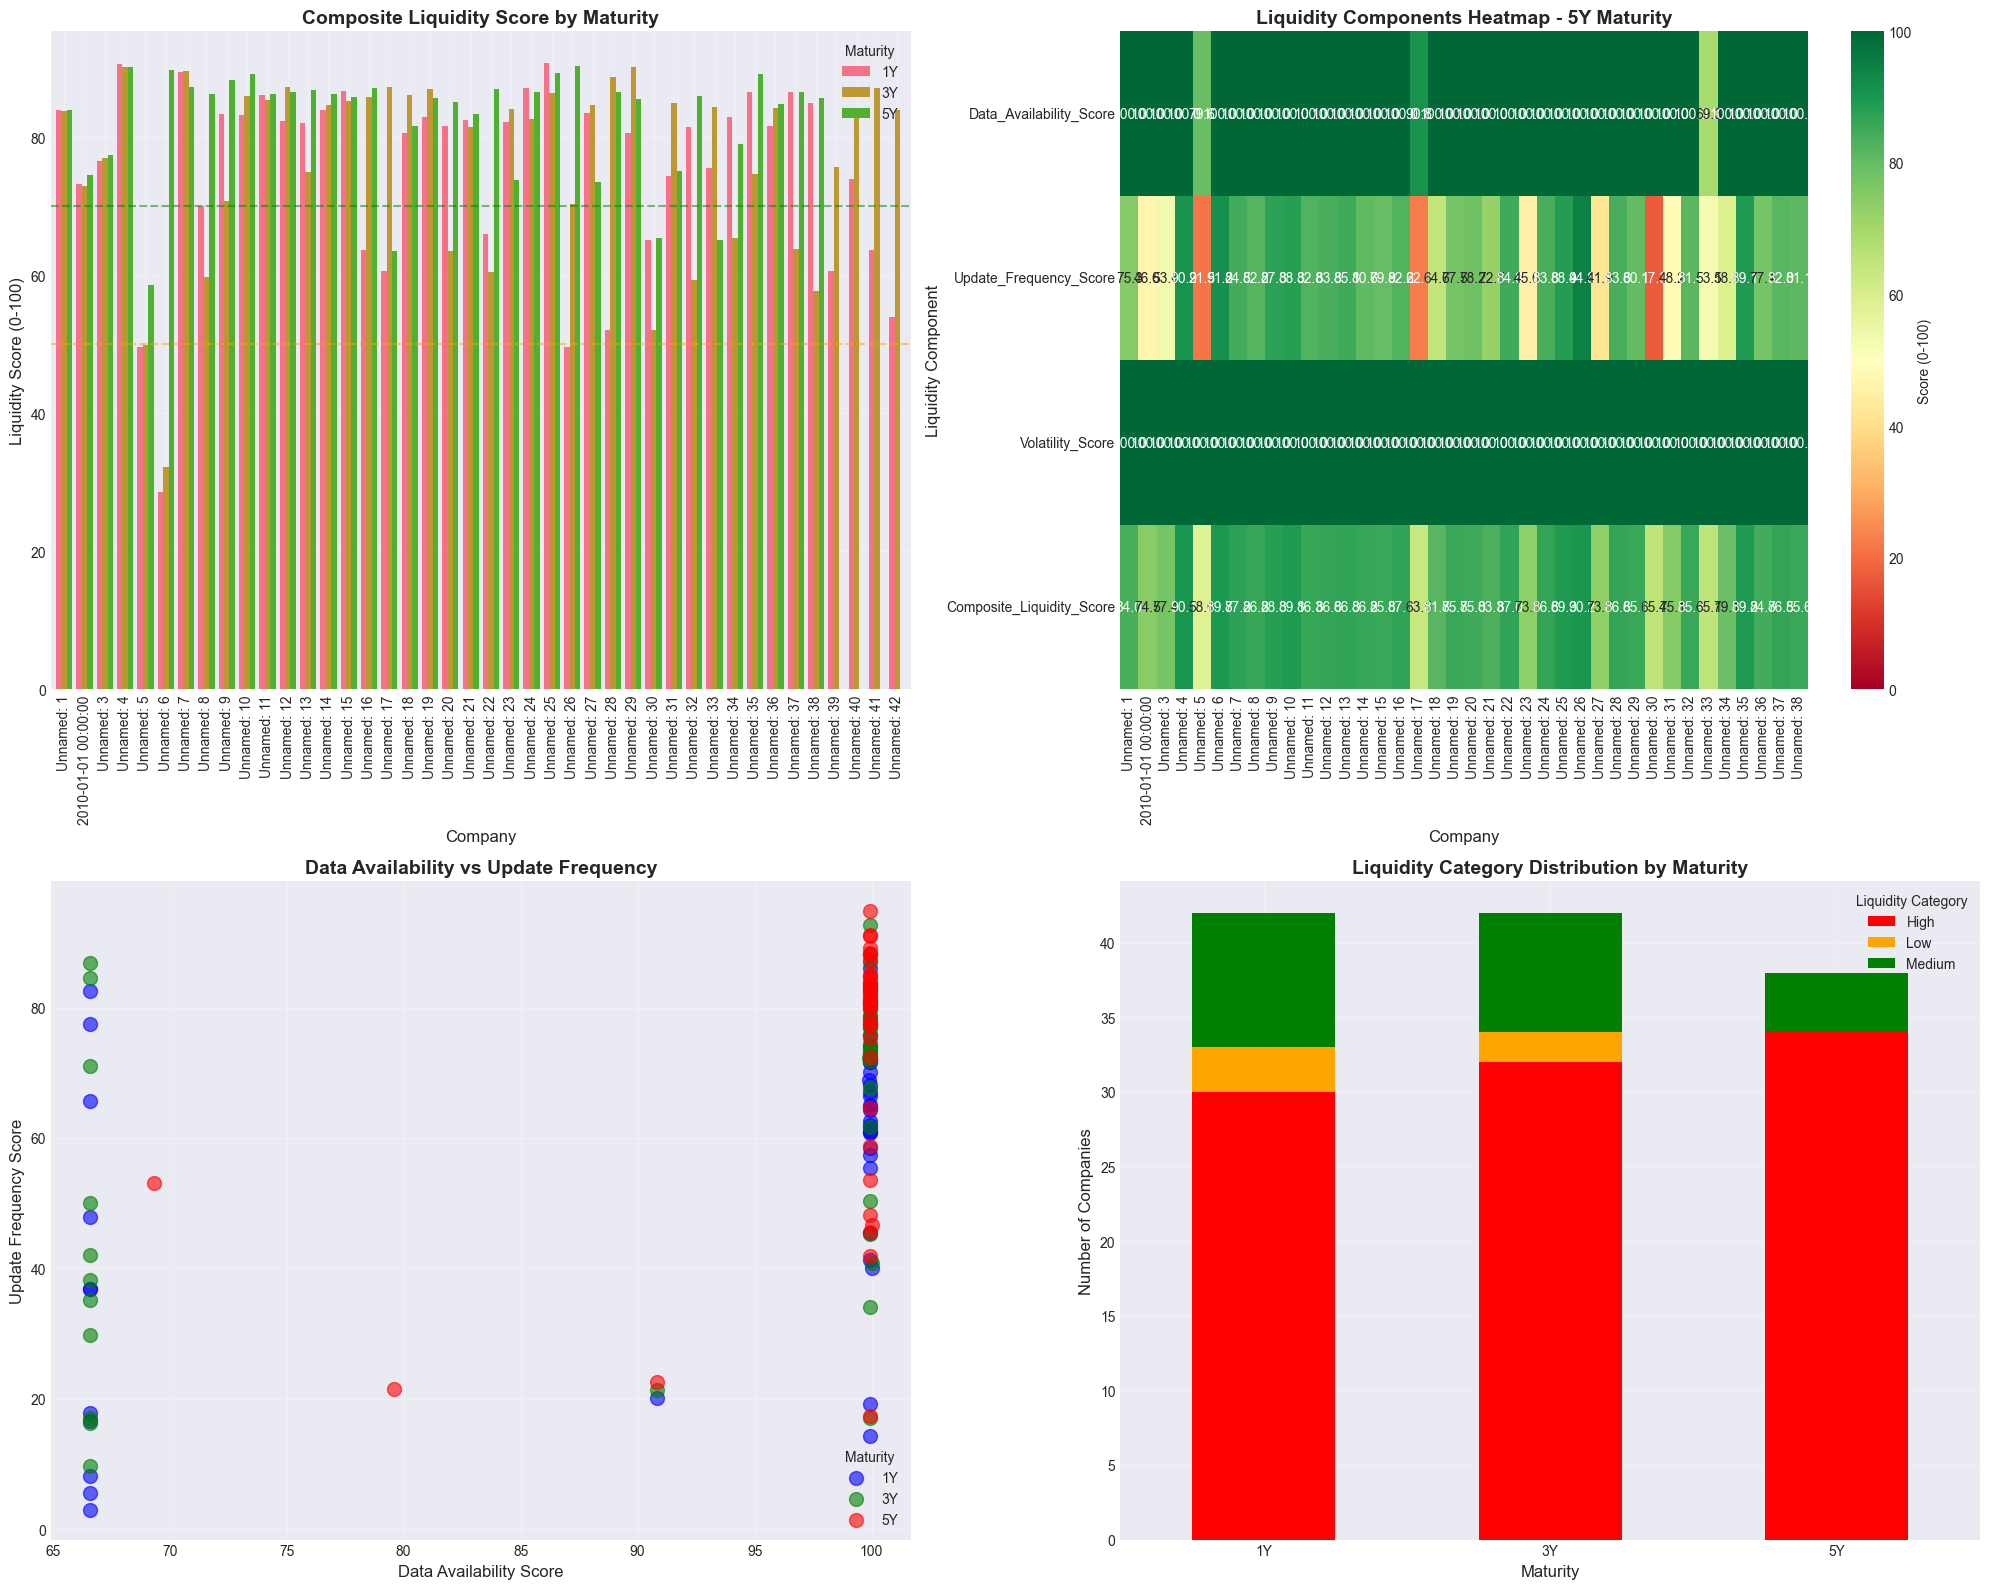


Comprehensive liquidity visualization saved!


In [35]:
# Create comprehensive liquidity comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Composite Liquidity Score Comparison
ax1 = axes[0, 0]

# Normalize index labels to string to avoid mixed-type index union errors.
liq_1 = pd.to_numeric(liquidity_1y["Composite_Liquidity_Score"], errors="coerce")
liq_3 = pd.to_numeric(liquidity_3y["Composite_Liquidity_Score"], errors="coerce")
liq_5 = pd.to_numeric(liquidity_5y["Composite_Liquidity_Score"], errors="coerce")
liq_1.index = liq_1.index.map(str)
liq_3.index = liq_3.index.map(str)
liq_5.index = liq_5.index.map(str)

liquidity_comparison = pd.concat(
    [liq_1.rename("1Y"), liq_3.rename("3Y"), liq_5.rename("5Y")],
    axis=1,
)
liquidity_comparison.plot(kind="bar", ax=ax1, width=0.8)
ax1.set_title("Composite Liquidity Score by Maturity", fontsize=14, fontweight="bold")
ax1.set_xlabel("Company", fontsize=12)
ax1.set_ylabel("Liquidity Score (0-100)", fontsize=12)
ax1.legend(title="Maturity", fontsize=10)
ax1.tick_params(axis="x", rotation=90)
ax1.axhline(y=70, color="green", linestyle="--", alpha=0.5, label="High Liquidity")
ax1.axhline(y=50, color="orange", linestyle="--", alpha=0.5, label="Medium Liquidity")
ax1.grid(True, alpha=0.3)

# Plot 2: Liquidity Components Heatmap (5Y as example)
ax2 = axes[0, 1]
liquidity_components = liquidity_5y[[
    "Data_Availability_Score",
    "Update_Frequency_Score",
    "Volatility_Score",
    "Composite_Liquidity_Score",
]].apply(pd.to_numeric, errors="coerce")
liquidity_components.index = liquidity_components.index.map(str)
liquidity_components = liquidity_components.T
sns.heatmap(
    liquidity_components,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    ax=ax2,
    cbar_kws={"label": "Score (0-100)"},
    vmin=0,
    vmax=100,
)
ax2.set_title("Liquidity Components Heatmap - 5Y Maturity", fontsize=14, fontweight="bold")
ax2.set_xlabel("Company", fontsize=12)
ax2.set_ylabel("Liquidity Component", fontsize=12)

# Plot 3: Data Availability vs Update Frequency
ax3 = axes[1, 0]
for maturity, liquidity_df, color in zip(
    ["1Y", "3Y", "5Y"],
    [liquidity_1y, liquidity_3y, liquidity_5y],
    ["blue", "green", "red"],
):
    x = pd.to_numeric(liquidity_df["Data_Availability_Score"], errors="coerce")
    y = pd.to_numeric(liquidity_df["Update_Frequency_Score"], errors="coerce")
    ax3.scatter(x, y, s=100, alpha=0.6, label=maturity, color=color)

ax3.set_title("Data Availability vs Update Frequency", fontsize=14, fontweight="bold")
ax3.set_xlabel("Data Availability Score", fontsize=12)
ax3.set_ylabel("Update Frequency Score", fontsize=12)
ax3.legend(title="Maturity", fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Liquidity Category Distribution
ax4 = axes[1, 1]
liquidity_categories = pd.DataFrame({
    "1Y": liquidity_1y["Liquidity_Category"].astype(str).value_counts(),
    "3Y": liquidity_3y["Liquidity_Category"].astype(str).value_counts(),
    "5Y": liquidity_5y["Liquidity_Category"].astype(str).value_counts(),
}).T.fillna(0)

liquidity_categories.plot(kind="bar", stacked=True, ax=ax4, color=["red", "orange", "green"])
ax4.set_title("Liquidity Category Distribution by Maturity", fontsize=14, fontweight="bold")
ax4.set_xlabel("Maturity", fontsize=12)
ax4.set_ylabel("Number of Companies", fontsize=12)
ax4.legend(title="Liquidity Category", fontsize=10)
ax4.tick_params(axis="x", rotation=0)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / "liquidity_comprehensive_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nComprehensive liquidity visualization saved!")

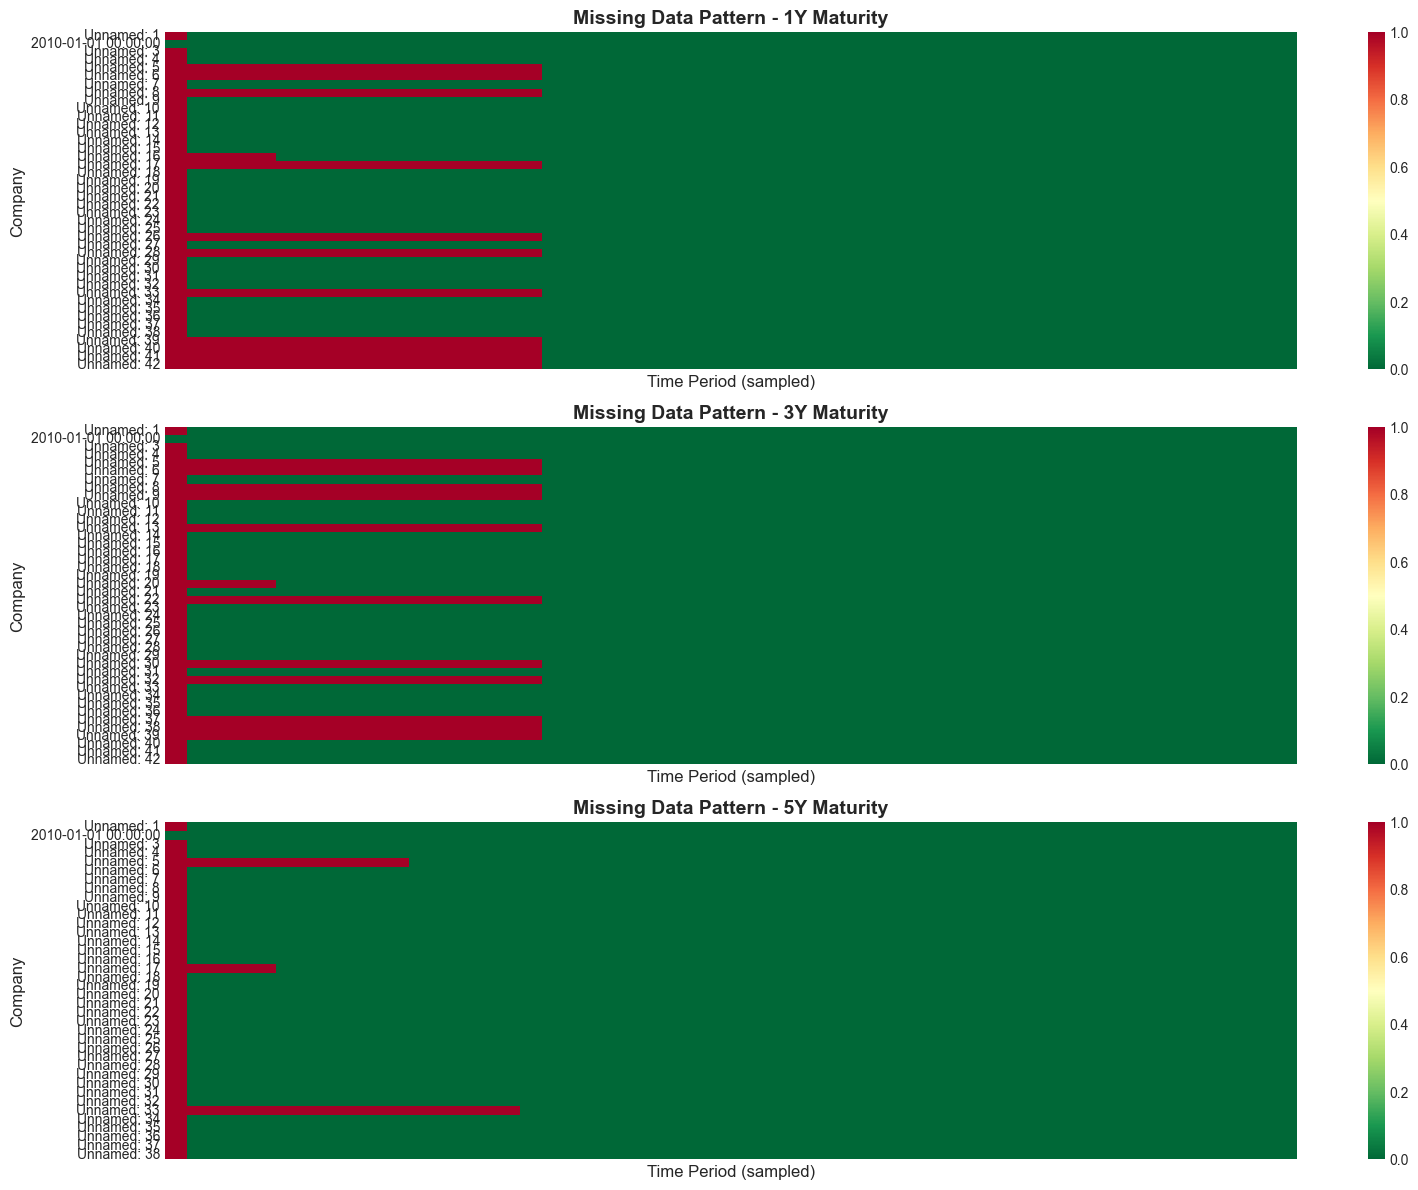


Missing data heatmap saved!


In [36]:
# Create missing data heatmap across all maturities
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for idx, (df, maturity, ax) in enumerate(zip([cds_1y, cds_3y, cds_5y], 
                                               ['1Y', '3Y', '5Y'], 
                                               axes)):
    # Create binary matrix of missing data (sample every 20th row for visibility)
    sample_freq = max(1, len(df) // 50)
    missing_matrix = df.iloc[::sample_freq].isna().T
    
    sns.heatmap(missing_matrix, cmap='RdYlGn_r', cbar=True, ax=ax,
                xticklabels=False, yticklabels=True)
    ax.set_title(f'Missing Data Pattern - {maturity} Maturity', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Period (sampled)', fontsize=12)
    ax.set_ylabel('Company', fontsize=12)

plt.tight_layout()
plt.savefig(output_path / 'missing_data_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMissing data heatmap saved!")

## Summary and Key Findings

Generate a summary report of key findings from the data quality analysis.

In [37]:
# Generate summary report
print("="*80)
print("SUMMARY REPORT: CDS RAW DATA QUALITY ANALYSIS")
print("="*80)

for maturity, stats_df, missing_df, repeat_df, liquidity_df in zip(
    ['1-Year', '3-Year', '5-Year'],
    [stats_1y, stats_3y, stats_5y],
    [missing_1y, missing_3y, missing_5y],
    [repeats_1y, repeats_3y, repeats_5y],
    [liquidity_1y, liquidity_3y, liquidity_5y]
):
    print(f"\n{'='*80}")
    print(f"{maturity} Maturity Summary")
    print(f"{'='*80}")
    
    print(f"\n1. Data Availability:")
    print(f"   - Best coverage: {missing_df['Data_Availability'].idxmax()} "
          f"({missing_df['Data_Availability'].max():.2f}%)")
    print(f"   - Worst coverage: {missing_df['Data_Availability'].idxmin()} "
          f"({missing_df['Data_Availability'].min():.2f}%)")
    print(f"   - Average coverage: {missing_df['Data_Availability'].mean():.2f}%")
    
    print(f"\n2. Data Staleness (Sequential Repeats):")
    print(f"   - Most stale: {repeat_df['Repeat_Percentage'].idxmax()} "
          f"({repeat_df['Repeat_Percentage'].max():.2f}%)")
    print(f"   - Least stale: {repeat_df['Repeat_Percentage'].idxmin()} "
          f"({repeat_df['Repeat_Percentage'].min():.2f}%)")
    print(f"   - Average staleness: {repeat_df['Repeat_Percentage'].mean():.2f}%")
    
    print(f"\n3. Liquidity Metrics:")
    print(f"   - Most liquid: {liquidity_df['Composite_Liquidity_Score'].idxmax()} "
          f"(Score: {liquidity_df['Composite_Liquidity_Score'].max():.2f})")
    print(f"   - Least liquid: {liquidity_df['Composite_Liquidity_Score'].idxmin()} "
          f"(Score: {liquidity_df['Composite_Liquidity_Score'].min():.2f})")
    print(f"   - Average liquidity score: {liquidity_df['Composite_Liquidity_Score'].mean():.2f}")
    
    # Liquidity distribution
    high_liquidity = (liquidity_df['Liquidity_Category'] == 'High').sum()
    medium_liquidity = (liquidity_df['Liquidity_Category'] == 'Medium').sum()
    low_liquidity = (liquidity_df['Liquidity_Category'] == 'Low').sum()
    
    print(f"\n4. Liquidity Distribution:")
    print(f"   - High liquidity companies: {high_liquidity}")
    print(f"   - Medium liquidity companies: {medium_liquidity}")
    print(f"   - Low liquidity companies: {low_liquidity}")
    
    print(f"\n5. Spread Statistics:")
    print(f"   - Highest average spread: {stats_df['Mean'].idxmax()} "
          f"({stats_df['Mean'].max():.2f} bps)")
    print(f"   - Lowest average spread: {stats_df['Mean'].idxmin()} "
          f"({stats_df['Mean'].min():.2f} bps)")
    print(f"   - Most volatile: {stats_df['Std'].idxmax()} "
          f"(Std: {stats_df['Std'].max():.2f} bps)")

print("\n" + "="*80)
print("Analysis complete! All results have been exported.")
print("="*80)

SUMMARY REPORT: CDS RAW DATA QUALITY ANALYSIS

1-Year Maturity Summary

1. Data Availability:
   - Best coverage: 2010-01-01 00:00:00 (100.00%)
   - Worst coverage: Unnamed: 5 (66.59%)
   - Average coverage: 91.00%

2. Data Staleness (Sequential Repeats):
   - Most stale: Unnamed: 6 (97.02%)
   - Least stale: Unnamed: 25 (13.93%)
   - Average staleness: 45.98%

3. Liquidity Metrics:
   - Most liquid: Unnamed: 25 (Score: 90.78)
   - Least liquid: Unnamed: 6 (Score: 28.64)
   - Average liquidity score: 75.34

4. Liquidity Distribution:
   - High liquidity companies: 30
   - Medium liquidity companies: 9
   - Low liquidity companies: 3

5. Spread Statistics:
   - Highest average spread: Unnamed: 6 (250.34 bps)
   - Lowest average spread: Unnamed: 42 (10.77 bps)
   - Most volatile: Unnamed: 25 (Std: 67.88 bps)

3-Year Maturity Summary

1. Data Availability:
   - Best coverage: 2010-01-01 00:00:00 (100.00%)
   - Worst coverage: Unnamed: 5 (66.59%)
   - Average coverage: 91.00%

2. Data Stal

## Conclusions

### Liquidity Metric Methodology

The **Composite Liquidity Score** is calculated as a weighted average of four components:

1. **Data Availability Score (40% weight)**: Percentage of non-missing observations
   - Higher score = more complete data coverage

2. **Update Frequency Score (30% weight)**: Inverse of the sequential repeat percentage
   - Higher score = data updates more frequently (less stale)

3. **Volatility Score (20% weight)**: Normalized annualized volatility
   - Higher volatility suggests more active trading and price discovery

4. **Daily Range Score (10% weight)**: Average daily spread changes relative to level
   - Higher range suggests better price discovery and liquidity

### Interpretation Guidelines

- **High Liquidity** (Score ≥ 70): Good data quality, frequent updates, actively traded
- **Medium Liquidity** (50 ≤ Score < 70): Acceptable quality with some limitations
- **Low Liquidity** (Score < 50): Poor data quality, stale prices, illiquid market

### Recommendations

1. Use companies with **High Liquidity** scores for primary analysis
2. Apply caution when using data with high sequential repeat percentages
3. Consider excluding companies with >20% missing data
4. The 5-year maturity typically shows the best liquidity across most names